# GRÁFICA DE DISTRIBUCIÓN DE ENERGÍA POR CONTINENTE

In [3]:
import pandas as pd
import numpy as np

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.diagnostics import cross_validation,performance_metrics
from prophet.plot import plot_cross_validation_metric

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools

import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:


# Create a continent mapping
continent_map = {
    'Africa': ['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo', 'Cote d\'Ivoire', 'Democratic Republic of the Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'],
    'Asia': ['Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan', 'Brunei Darussalam', 'Cambodia', 'China', 'Cyprus', 'Georgia', 'India', 'Indonesia', 'Iran', 'Iraq', 'Israel', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon', 'Malaysia','Maldives', 'Mongolia', 'Myanmar', 'Nepal', 'North Korea', 'Oman', 'Pakistan', 'Palestine', 'Philippines', 'Qatar', 'Saudi Arabia', 'Singapore', 'South Korea', 'Sri Lanka', 'Syria', 'Taiwan', 'Tajikistan', 'Thailand', 'Timor-Leste', 'Turkey', 'Turkmenistan', 'United Arab Emirates', 'Uzbekistan', 'Vietnam', 'Yemen'],
    'Europe': ['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom', 'Vatican City'],
    'North America': ['Canada', 'Greenland', 'Mexico', 'United States'],
    'Oceania': ['Australia', 'Fiji', 'New Zealand', 'Papua New Guinea'],
    'South America': ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela']
}


In [5]:
dataset = pd.read_csv ("World Energy Consumption.csv")

In [6]:
col_electricity = ['low_carbon_electricity',
            'nuclear_electricity',
            'oil_electricity',
            'other_renewable_electricity',
            'other_renewable_exc_biofuel_electricity',
            'solar_electricity',
            'wind_electricity',
            'fossil_electricity',
            'gas_electricity',
            'hydro_electricity',
            'biofuel_electricity',
            'coal_electricity']
col_cons =['biofuel_consumption',
           'coal_consumption',
           'fossil_fuel_consumption',
           'gas_consumption',
           'hydro_consumption',
           'low_carbon_consumption',
           'nuclear_consumption',
           'oil_consumption',
           'solar_consumption']

In [7]:
#segundo dataframe que incluye columna con datos de consumo / dato exogeno

dataset_exog_1= dataset.groupby(['year','country'])[col_electricity].sum().sum(axis=1).to_frame('electricity_generation').reset_index("country")
dataset_exog_2 = dataset.groupby(["year", "country"])[col_cons].sum().sum(axis=1).to_frame('electricty_consumption').reset_index('country')

dataset_exog = pd.merge(dataset_exog_1, dataset_exog_2, on=['year', 'country'])

dataset_exog['continent'] = dataset_exog['country'].map(lambda x: next((k for k, v in continent_map.items() if x in v), None))
dataset_exog = dataset_exog[dataset_exog['continent'].notna()]

data_1986 = dataset_exog[dataset_exog.index>1985].reset_index()

In [8]:
data_1986.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5657 entries, 0 to 5656
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    5657 non-null   int64  
 1   country                 5657 non-null   object 
 2   electricity_generation  5657 non-null   float64
 3   electricty_consumption  5657 non-null   float64
 4   continent               5657 non-null   object 
dtypes: float64(2), int64(1), object(2)
memory usage: 221.1+ KB


In [9]:
data_1986.groupby('country')['electricity_generation'].sum().sort_values(ascending=False).head(15)

country
United States     281111.644
China             239240.606
Japan              72269.952
Russia             71091.008
India              60529.817
Germany            43876.374
Canada             43155.912
France             38081.248
Brazil             30964.994
United Kingdom     26126.157
South Korea        25694.850
Italy              19986.694
Spain              17265.238
Mexico             16588.304
South Africa       15469.888
Name: electricity_generation, dtype: float64

## Prophet por pais o continente

In [ ]:
data_1986[data_1986['country']=='South Africa']['electricity_generation'].plot()

## Funcion Prophet con pruebas de impresion usando Plotly

In [ ]:

def prophet(dato,lugar):
    if lugar in dato['continent'].values:
        dato = dato.groupby(['year','continent'])[['electricity_generation', 'electricty_consumption']].sum().reset_index()
        dato = dato[dato['continent']==lugar]
        print(dato)
    elif lugar in dato['country'].values:
        dato = dato.groupby(['year','country'])[['electricity_generation', 'electricty_consumption']].sum().reset_index()
        dato = dato[dato['country']==lugar]
        print(dato)
    else:
        return None
    # Crear una copia temporal de los datos
    prophet_data = dato.copy()
    prophet_data['ds'] = pd.to_datetime(prophet_data['year'], format='%Y')
    prophet_data['y'] = prophet_data['electricity_generation']

    #prophet_data['electricty_consumption'] = prophet_data['electricty_consumption']

    # Definir la grilla de parámetros para optimización
    param_grid = {
        'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5, 1],
        'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
        'seasonality_mode': ['additive', 'multiplicative']
    }

    # Generar todas las combinaciones de parámetros
    all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
    rmses = []

    # Usar el 70% de los datos para entrenamiento
    train_size = int(len(prophet_data) * 0.7)
    train_data = prophet_data.iloc[:train_size]
    test_data = prophet_data.iloc[train_size:]

    print("Finding best parameters...")
    best_rmse = float('inf')
    best_params = None

    for params in all_params:
        # Crear y ajustar el modelo con cada combinación de parámetros
        model = Prophet(
            yearly_seasonality=True,
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            seasonality_mode=params['seasonality_mode']
        )
        model.add_regressor('electricty_consumption')
        model.fit(train_data)

        # Generar el dataframe futuro para el periodo de test
        future = model.make_future_dataframe(periods=len(test_data), freq='Y')
        # Incorporar la variable externa en el futuro
        future = future.merge(prophet_data[['ds', 'electricty_consumption']], on='ds', how='left')
        # Rellenar valores faltantes (por ejemplo, usando el último valor observado)
        future['electricty_consumption'] = future['electricty_consumption'].fillna(method='ffill')

        forecast = model.predict(future)

        # Calcular el error para el periodo de test
        test_predictions = forecast.iloc[-len(test_data):]
        rmse = np.sqrt(mean_squared_error(test_data['y'], test_predictions['yhat']))
        rmses.append(rmse)

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    print("\nBest parameters:")
    for param, value in best_params.items():
        print(f"{param}: {value}")
    print(f"Best RMSE: {best_rmse:.2f}")

    # Ajustar el modelo final con los mejores parámetros
    final_model = Prophet(
        yearly_seasonality=True,
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        seasonality_prior_scale=best_params['seasonality_prior_scale'],
        seasonality_mode=best_params['seasonality_mode']
    )
    final_model.add_regressor('electricty_consumption')
    final_model.fit(prophet_data)

    # Crear el dataframe futuro para 5 periodos adicionales
    future = final_model.make_future_dataframe(periods=5, freq='Y')
    # Incorporar el regressor en el dataframe futuro
    future = future.merge(prophet_data[['ds', 'electricty_consumption']], on='ds', how='left')
    future['electricty_consumption'] = future['electricty_consumption'].fillna(method='ffill')

    forecast = final_model.predict(future)

    fig = go.Figure()

# Datos reales
    fig.add_trace(go.Scatter(x=prophet_data['ds'], y=prophet_data['y'],
                         mode='lines', name="Datos reales",
                         line=dict(color='red')))

# Predicción
    fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat'],
                         mode='lines', name="Predicción",
                         line=dict(color='blue')))

# Intervalo de confianza
    fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_upper'],
                         mode='lines', name="Límite superior",
                         line=dict(color='blue', width=0),
                         showlegend=False))
    fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_lower'],
                         mode='lines', name="Límite inferior",
                         line=dict(color='blue', width=0),
                         fill='tonexty', fillcolor='rgba(0,0,255,0.2)',
                         showlegend=True))

# Etiquetas y diseño
    fig.update_layout(width=900,height=700,
    title=f"Predicción de Generación de Electricidad con Prophet {lugar}",
    xaxis_title="Año",
    yaxis_title="Generación de electricidad",
    template="plotly_white"
    )


    fig.show()

# Print additional metrics for test set
    mae = mean_absolute_error(test_data['y'], test_predictions['yhat'])
    mape = np.mean(np.abs((test_data['y'] - test_predictions['yhat']) / test_data['y'])) * 100

    f_cv = cross_validation(final_model, initial='730 days', period='365 days', horizon='365 days')
    #print(f_cv)

    print("\nTest Set Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {best_rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    df_p = performance_metrics(f_cv)
    print(df_p.head(10))
    fig = plot_cross_validation_metric(f_cv, metric='mape')

10:31:35 - cmdstanpy - INFO - Chain [1] start processing
10:31:35 - cmdstanpy - INFO - Chain [1] done processing


      year country  electricity_generation  electricty_consumption
22    1986  Canada                 936.894                5763.891
164   1987  Canada                 992.476                5947.842
306   1988  Canada                1011.640                6185.756
448   1989  Canada                 995.982                6243.682
590   1990  Canada                 960.882                6004.535
737   1991  Canada                1013.686                6028.932
886   1992  Canada                1036.938                6189.024
1039  1993  Canada                1060.134                6344.462
1192  1994  Canada                1105.780                6583.836
1346  1995  Canada                1112.615                6740.814
1500  1996  Canada                1139.952                6923.855
1654  1997  Canada                1141.298                6956.232
1809  1998  Canada                1120.395                6853.467
1964  1999  Canada                1151.960                7072

10:31:35 - cmdstanpy - INFO - Chain [1] start processing
10:31:35 - cmdstanpy - INFO - Chain [1] done processing
10:31:35 - cmdstanpy - INFO - Chain [1] start processing
10:31:36 - cmdstanpy - INFO - Chain [1] done processing
10:31:36 - cmdstanpy - INFO - Chain [1] start processing
10:31:36 - cmdstanpy - INFO - Chain [1] done processing
10:31:36 - cmdstanpy - INFO - Chain [1] start processing
10:31:36 - cmdstanpy - INFO - Chain [1] done processing
10:31:36 - cmdstanpy - INFO - Chain [1] start processing
10:31:36 - cmdstanpy - INFO - Chain [1] done processing
10:31:36 - cmdstanpy - INFO - Chain [1] start processing
10:31:36 - cmdstanpy - INFO - Chain [1] done processing
10:31:36 - cmdstanpy - INFO - Chain [1] start processing
10:31:36 - cmdstanpy - INFO - Chain [1] done processing
10:31:36 - cmdstanpy - INFO - Chain [1] start processing
10:31:36 - cmdstanpy - INFO - Chain [1] done processing
10:31:36 - cmdstanpy - INFO - Chain [1] start processing
10:31:37 - cmdstanpy - INFO - Chain [1]


Best parameters:
changepoint_prior_scale: 0.1
seasonality_prior_scale: 10.0
seasonality_mode: additive
Best RMSE: 47.45


  0%|          | 0/34 [00:00<?, ?it/s]

10:31:43 - cmdstanpy - INFO - Chain [1] start processing
10:31:45 - cmdstanpy - INFO - Chain [1] done processing
10:31:45 - cmdstanpy - INFO - Chain [1] start processing
10:31:46 - cmdstanpy - INFO - Chain [1] done processing
10:31:46 - cmdstanpy - INFO - Chain [1] start processing
10:31:46 - cmdstanpy - INFO - Chain [1] done processing
10:31:46 - cmdstanpy - INFO - Chain [1] start processing
10:31:49 - cmdstanpy - INFO - Chain [1] done processing
10:31:49 - cmdstanpy - INFO - Chain [1] start processing
10:31:49 - cmdstanpy - INFO - Chain [1] done processing
10:31:49 - cmdstanpy - INFO - Chain [1] start processing
10:31:49 - cmdstanpy - INFO - Chain [1] done processing
10:31:49 - cmdstanpy - INFO - Chain [1] start processing
10:31:50 - cmdstanpy - INFO - Chain [1] done processing
10:31:50 - cmdstanpy - INFO - Chain [1] start processing
10:31:55 - cmdstanpy - INFO - Chain [1] done processing
10:31:55 - cmdstanpy - INFO - Chain [1] start processing
10:31:55 - cmdstanpy - INFO - Chain [1]


Test Set Metrics:
MAE: 103.23
RMSE: 47.45
MAPE: nan%
   horizon            mse        rmse         mae      mape     mdape  \
0 357 days  329439.902286  573.968555  400.498191  0.404999  0.246078   
1 358 days    1333.868703   36.522167   35.806679  0.032446  0.033108   
2 359 days     127.075496   11.272777   10.071969  0.008823  0.007972   
3 360 days     365.951857   19.129868   14.949955  0.012893  0.009814   
4 361 days    1050.483085   32.411157   25.485209  0.020826  0.013262   
5 362 days     287.970143   16.969683   12.764994  0.010723  0.005293   
6 363 days     449.594470   21.203643   19.396326  0.015025  0.014301   
7 364 days     689.871518   26.265405   23.759194  0.018700  0.021586   
8 365 days     309.640873   17.596615   14.666636  0.011511  0.011086   

      smape  coverage  
0  0.617928      0.00  
1  0.032169      0.00  
2  0.008837      0.75  
3  0.012773      0.50  
4  0.021184      0.50  
5  0.010634      0.75  
6  0.015161      0.50  
7  0.018573      0.25  

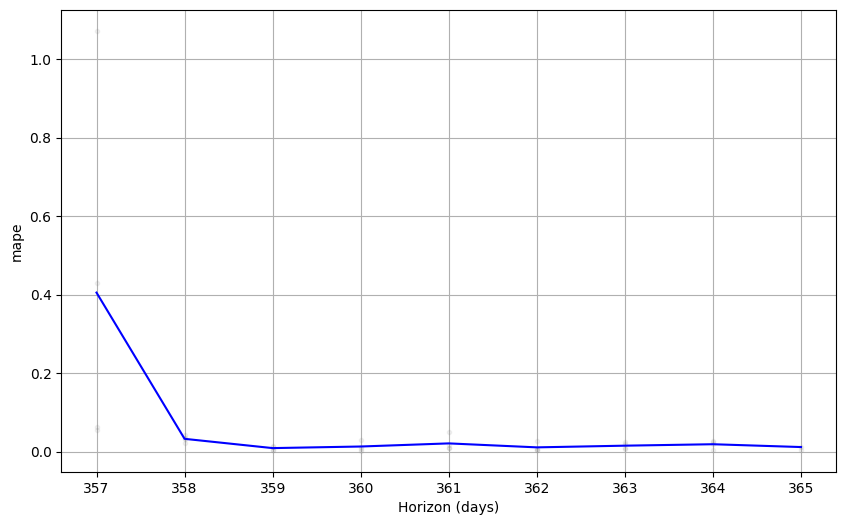

In [21]:
lugar='Canada'
prophet(data_1986,lugar)
